# 08 - Comparaison finale

## Objectif

Comparer l'approche classique par règles et l'approche Machine Learning avec SVM sur les mêmes images de test.

In [1]:
from pathlib import Path
import sys
import json

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

%load_ext autoreload
%autoreload 2

import pandas as pd

from src.evaluation import compute_metrics, metrics_table, plot_confusion_matrix, save_metrics
from src.rules import calibrate_rules_from_ok_samples, predict_dataframe_by_rules
from src.utils import FEATURES_DIR, FIGURES_DIR, METRICS_DIR, MODELS_DIR

try:
    from src.ml_models import load_model, prepare_xy, save_model, train_svm
    SKLEARN_AVAILABLE = True
except ModuleNotFoundError:
    SKLEARN_AVAILABLE = False

## 1. Chargement des caractéristiques

La comparaison se fait sur le fichier généré dans le notebook 06.

In [2]:
features_path = FEATURES_DIR / "casting_features.csv"
if not features_path.exists():
    raise FileNotFoundError("Lancez d'abord le notebook 06 pour g?n?rer les caract?ristiques.")

features_df = pd.read_csv(features_path)
train_df = features_df[features_df["split"] == "train"].copy()
test_df = features_df[features_df["split"] == "test"].copy()

print("Source des caract?ristiques :", features_path)
print("Train:", train_df.shape)
print("Test:", test_df.shape)
display(features_df.groupby(["split", "label_name"]).size().reset_index(name="count"))

Source des caract?ristiques : C:\Users\espacegamers\Desktop\Master IAII\Cours\drive-download-20251005T182208Z-1-001\S2\Traitement d_images et vision par ordinateur_\Projet\industrial-defect-detection2\data\features\casting_features.csv
Train: (6633, 56)
Test: (715, 56)


,split,label_name,count
0,test,Defective,453
1,test,OK,262
2,train,Defective,3758
3,train,OK,2875


## 2. Approche classique : règles

Les seuils sont calibrés sur les images OK du train, puis appliqués au test.

In [3]:
rule_config = calibrate_rules_from_ok_samples(features_df)
rule_pred = predict_dataframe_by_rules(test_df, rule_config).astype(int)
rule_metrics = compute_metrics(test_df["label"], rule_pred)

rule_metadata = {
    "source_features": str(features_path),
    "test_rows": int(len(test_df)),
    "test_ok": int((test_df["label"] == 0).sum()),
    "test_defective": int((test_df["label"] == 1).sum()),
    "rule_config": rule_config.__dict__,
}

print("Configuration des r?gles :")
display(pd.DataFrame([rule_config.__dict__]))
print("M?triques r?gles recalcul?es depuis src/rules.py :")
display(pd.DataFrame([rule_metrics]))

save_metrics(rule_metrics, METRICS_DIR / "rules_metrics.json")
save_metrics({"metrics": rule_metrics, "metadata": rule_metadata}, METRICS_DIR / "rules_metrics_detailed.json")

Configuration des r?gles :


,max_defect_area_ratio,max_largest_defect_area_ratio,max_defect_count,max_intensity_mean,max_intensity_p90,min_dark_pixel_ratio,min_hist_01_ratio,min_defect_count,min_texture_dissimilarity,min_rule_score
0,0.406829,0.250385,13.2,153.77269,214.0,0.118061,0.047883,9.0,0.419325,3.0


M?triques r?gles recalcul?es depuis src/rules.py :


,accuracy,precision,recall,f1_score
0,0.827972,0.796763,0.977925,0.878097


## 3. Approche Machine Learning : SVM

On charge le modèle déjà sauvegardé. S'il n'existe pas encore, on l'entraîne directement.

In [4]:
svm_metrics_path = METRICS_DIR / "svm_metrics.json"
model_path = MODELS_DIR / "svm_model.joblib"

if SKLEARN_AVAILABLE:
    X_train, y_train, feature_columns = prepare_xy(features_df, split="train")
    X_test, y_test, _ = prepare_xy(features_df, split="test", feature_columns=feature_columns)

    if model_path.exists():
        model = load_model(model_path)
    else:
        model = train_svm(X_train, y_train)
        save_model(model, model_path)

    svm_pred = model.predict(X_test)
    svm_metrics = compute_metrics(y_test, svm_pred)
    save_metrics(svm_metrics, svm_metrics_path)
    print("M?triques SVM recalcul?es avec le mod?le sauvegard?.")
else:
    if not svm_metrics_path.exists():
        raise ModuleNotFoundError("scikit-learn n'est pas install? et aucun fichier svm_metrics.json n'est disponible.")
    with svm_metrics_path.open("r", encoding="utf-8") as file:
        svm_metrics = json.load(file)
    y_test = test_df["label"]
    svm_pred = None
    print("scikit-learn n'est pas disponible dans cet environnement : m?triques SVM charg?es depuis", svm_metrics_path)

display(pd.DataFrame([svm_metrics]))

M?triques SVM recalcul?es avec le mod?le sauvegard?.


,accuracy,precision,recall,f1_score
0,0.997203,0.995604,1.0,0.997797


## 4. Tableau comparatif

Les deux approches sont évaluées avec les mêmes métriques.

In [7]:
comparison = metrics_table({
    "Traitement d'image + regles": rule_metrics,
    "Traitement d'image + SVM": svm_metrics,
})

comparison_path = METRICS_DIR / "comparison_metrics.csv"
comparison_json_path = METRICS_DIR / "comparison_metrics.json"
comparison.to_csv(comparison_path, index=False)
save_metrics(
    {
        "source_features": str(features_path),
        "rules_source": "src/rules.py recalcul? dans ce notebook",
        "svm_source": "mod?le recalcul?" if SKLEARN_AVAILABLE else str(svm_metrics_path),
        "metrics": comparison.to_dict(orient="records"),
    },
    comparison_json_path,
)

print("Comparaison sauvegard?e dans :", comparison_path)
display(comparison)

Comparaison sauvegard?e dans : C:\Users\espacegamers\Desktop\Master IAII\Cours\drive-download-20251005T182208Z-1-001\S2\Traitement d_images et vision par ordinateur_\Projet\industrial-defect-detection2\results\metrics\comparison_metrics.csv


,method,accuracy,precision,recall,f1_score
0,Traitement d'image + regles,0.827972,0.796763,0.977925,0.878097
1,Traitement d'image + SVM,0.997203,0.995604,1.000000,0.997797


## 5. Matrices de confusion

Les matrices de confusion permettent de voir le type d'erreurs : OK classées comme Defective ou Defective classées comme OK.

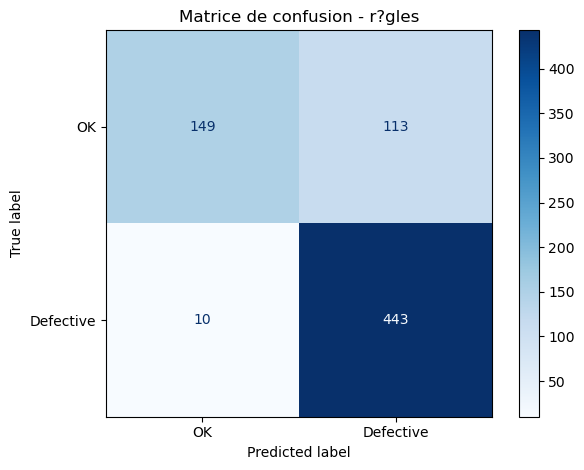

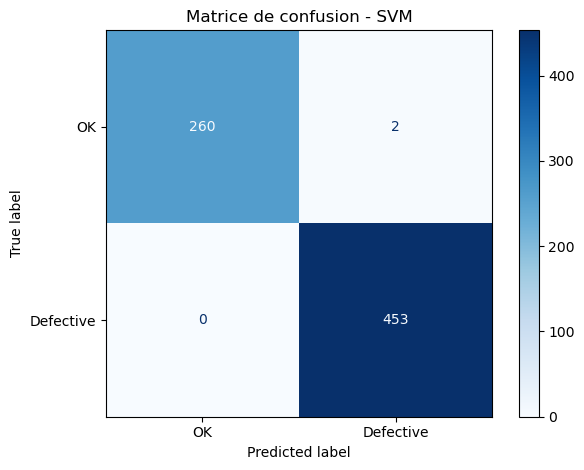

In [6]:
plot_confusion_matrix(test_df["label"], rule_pred, "Matrice de confusion - r?gles", FIGURES_DIR / "rules_confusion_matrix.png")

if svm_pred is not None:
    plot_confusion_matrix(y_test, svm_pred, "Matrice de confusion - SVM", FIGURES_DIR / "svm_confusion_matrix_comparison.png")
else:
    print("Matrice SVM non recalcul?e ici car scikit-learn n'est pas disponible dans cet environnement.")

## Interprétation simple

- L'approche par règles est facile à expliquer : elle s'appuie sur des seuils liés aux zones suspectes détectées.
- Elle est rapide, mais sensible à l'éclairage, au contraste et au choix des seuils.
- Le SVM exploite plus de caractéristiques : intensité, histogrammes, texture et mesures de segmentation.
- Le SVM peut mieux généraliser si les caractéristiques sont pertinentes, mais il est moins directement interprétable qu'une règle simple.
- La comparaison finale est utile car elle montre ce que l'on gagne en ajoutant du Machine Learning par rapport à une méthode classique.